# 08 — Score de Risco sobre Colaboradores Ativos (Set–Dez/2025)

**Objetivo:** Aplicar os modelos tunados à população de aplicação (`base_features_apl`,
Set–Dez/2025) calculando, para cada colaborador × mês, o **score de risco** reescalado
segundo a fórmula da Seção 14 do SPEC.

**Fórmula de score (SPEC §14):**
```
se prob >= T  →  score = 0.50 + ((prob − T) / (1.0 − T)) × 0.50
se prob >= M  →  score = 0.35 + ((prob − M) / (T − M)) × 0.15
senão         →  score = (prob / M) × 0.35
```
`T` = threshold tunado por grupo  
`M` = percentil 25 das probabilidades preditas no **treino** de cada grupo

**Grupos de risco:**

| Grupo | Score |
|---|---|
| Alto   | score ≥ 0.50 (prob ≥ T) |
| Médio  | 0.35 ≤ score < 0.50 |
| Baixo  | score < 0.35 |

---

| Entrada | Descrição |
|---|---|
| `data/gold/base_features_apl.parquet` | Base de aplicação Set–Dez/2025 (pré-scale) |
| `data/processed/splits/{grupo}/train.parquet` | Usado para calcular M (P25 train proba) |
| `data/processed/splits/{grupo}/scaler_cols.json` | Colunas a escalar + metadados |
| `models/{grupo}/standard_scaler.joblib` | Scaler fitado no treino |
| `models/{grupo}/best_model_tuned.joblib` | Modelo tunado |
| `models/{grupo}/tuning_metadata.json` | Threshold e metadados |
| `data/processed/feature_selection/{grupo}/selected_features.json` | Features canônicas |

| Saída | Descrição |
|---|---|
| `reports/score_risco_consolidado.parquet` | Score consolidado dos 3 grupos × 4 meses |
| `reports/score_risco_consolidado.csv` | Versão CSV para inspeção |
| `reports/figures/distribuicao_risco_grupos.png` | Distribuição de faixas por grupo |
| `reports/figures/histograma_score_grupos.png` | Histogramas de score reescalado |


## 1 · Setup & Configuração

In [7]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

os.environ["OMP_NUM_THREADS"]      = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"]      = "2"

print(f"pandas {pd.__version__}  ·  numpy {np.__version__}")
print(f"Execução: {datetime.now():%Y-%m-%d %H:%M}")


pandas 2.3.3  ·  numpy 2.3.5
Execução: 2026-04-13 20:51


In [8]:

# ════════════════════════════════════════════════════════════════
# CONFIGURAÇÃO
# ════════════════════════════════════════════════════════════════
PROJECT_ROOT = Path.cwd().parent
GOLD_DIR     = PROJECT_ROOT / "data" / "gold"
SPLITS_DIR   = PROJECT_ROOT / "data" / "processed" / "splits"
FS_DIR       = PROJECT_ROOT / "data" / "processed" / "feature_selection"
MODELS_DIR   = PROJECT_ROOT / "models"
REPORTS_DIR  = PROJECT_ROOT / "reports"
FIGURES_DIR  = REPORTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GRUPOS    = ["Vendas", "Transporte", "Fábrica"]
COL_ID    = "id_colaborador"
COL_GRUPO = "ds_grupo"
COL_DATA  = "dt_mes_ano"
COL_TARGET = "fg_demitido_voluntario_4m"

# Base histórica para cálculo das taxas de referência (Método 2)
BFTT_PATH = GOLD_DIR / "base_features_tt.parquet"

print(f"Grupos   : {GRUPOS}")
print(f"Base apl : {GOLD_DIR / 'base_features_apl.parquet'}")
print(f"Base TT  : {BFTT_PATH}")
print(f"Execução : {datetime.now():%Y-%m-%d %H:%M}")


Grupos   : ['Vendas', 'Transporte', 'Fábrica']
Base apl : g:\Meu Drive\Rafael\Desemprego\projetos github\projeto1_modelo_preditivo\data\gold\base_features_apl.parquet
Base TT  : g:\Meu Drive\Rafael\Desemprego\projetos github\projeto1_modelo_preditivo\data\gold\base_features_tt.parquet
Execução : 2026-04-13 20:51


## 2 · Funções de Score

In [9]:

def calcular_ref_rates(bftt: pd.DataFrame, grupo: str,
                       n_meses: int = 3) -> dict:
    """Calcula taxa de referência dos últimos n_meses de base_features_tt por grupo.

    Retorna:
        ref_rate  – média da taxa de turnover nos últimos n_meses
        alto_pct  – fração a classificar como Alto  (ref_rate × 1.4)
        medio_pct – fração a classificar como Médio (alto_pct × 0.5)
    """
    df_g     = bftt[bftt[COL_GRUPO] == grupo]
    ult_meses = sorted(df_g[COL_DATA].unique())[-n_meses:]
    ref_rate  = df_g[df_g[COL_DATA].isin(ult_meses)][COL_TARGET].mean()
    alto_pct  = ref_rate * 1.4
    medio_pct = alto_pct * 0.5
    return {"ref_rate": ref_rate, "alto_pct": alto_pct, "medio_pct": medio_pct}


def classificar_ranking(df_mes: pd.DataFrame, col_proba: str,
                        alto_pct: float, medio_pct: float) -> pd.Series:
    """Classifica colaboradores por ranking de probabilidade em um mês/grupo.

    Ordena por probabilidade decrescente:
      top    alto_pct  fraction → 'Alto'
      próximos medio_pct fraction → 'Médio'
      resto                       → 'Baixo'
    """
    n      = len(df_mes)
    n_alto = max(1, round(n * alto_pct))
    n_am   = max(1, round(n * (alto_pct + medio_pct)))
    rank   = df_mes[col_proba].rank(method="first", ascending=False)
    result = np.where(rank <= n_alto, "Alto",
             np.where(rank <= n_am,   "Médio", "Baixo"))
    return pd.Series(result, index=df_mes.index)


print("Funções de ranking (Método 2) carregadas.")


Funções de ranking (Método 2) carregadas.


## 3 · Score por Grupo

In [10]:

# ── Carregar bases ────────────────────────────────────────────
df_apl_all = pd.read_parquet(GOLD_DIR / "base_features_apl.parquet")
bftt       = pd.read_parquet(BFTT_PATH)

print(f"base_features_apl : {df_apl_all.shape}  "
      f"| meses: {sorted(df_apl_all[COL_DATA].dt.strftime('%Y-%m').unique())}")

score_frames = []
rate_params  = {}   # armazenar parâmetros de taxa por grupo para referência

for GRUPO in GRUPOS:
    print(f"\n{'='*65}")
    print(f"GRUPO: {GRUPO}")
    print('='*65)

    # ── Metadados e artefatos ─────────────────────────────────
    FEATURES   = json.loads(
        (FS_DIR / GRUPO / "selected_features.json").read_text(encoding="utf-8")
    )["selected_features"]
    meta_tuned = json.loads((MODELS_DIR / GRUPO / "tuning_metadata.json").read_text(encoding="utf-8"))
    sc_cfg     = json.loads((SPLITS_DIR / GRUPO / "scaler_cols.json").read_text(encoding="utf-8"))
    MODEL_NAME = meta_tuned["modelo"]

    model      = joblib.load(MODELS_DIR / GRUPO / "best_model_tuned.joblib")
    scaler     = joblib.load(MODELS_DIR / GRUPO / "standard_scaler.joblib")
    scale_cols = sc_cfg["scale_cols"]

    print(f"  Modelo  : {MODEL_NAME}  |  {len(FEATURES)} features")

    # ── Taxas de referência (Método 2 — últimos 3 meses de base_features_tt) ──
    rates = calcular_ref_rates(bftt, GRUPO, n_meses=3)
    rate_params[GRUPO] = rates
    print(f"  Ref rate (ult 3m TT) : {rates['ref_rate']*100:.2f}%  "
          f"| Alto: {rates['alto_pct']*100:.2f}%  "
          f"| Médio: {rates['medio_pct']*100:.2f}%  "
          f"| Alto+Médio: {(rates['alto_pct']+rates['medio_pct'])*100:.2f}%")

    # ── Filtrar e escalar base de aplicação ───────────────────
    df_g = df_apl_all[df_apl_all[COL_GRUPO] == GRUPO].copy()
    print(f"  Linhas apl : {len(df_g):,}  ({df_g[COL_DATA].nunique()} meses)")

    missing = [f for f in FEATURES if f not in df_g.columns]
    if missing:
        print(f"  ⚠ {len(missing)} feature(s) ausentes — preenchidas com 0: {missing[:5]}")
        for c in missing:
            df_g[c] = 0.0

    cols_to_scale = [c for c in scale_cols if c in df_g.columns]
    df_g[cols_to_scale] = scaler.transform(df_g[cols_to_scale])

    # ── Calcular probabilidades ───────────────────────────────
    X_apl = df_g[FEATURES].copy()
    proba = model.predict_proba(X_apl)[:, 1]

    # ── Construir tabela base (sem grupo_risco ainda) ─────────
    df_score = pd.DataFrame({
        COL_ID           : df_g[COL_ID].values,
        COL_GRUPO        : GRUPO,
        COL_DATA         : df_g[COL_DATA].values,
        "proba_turnover" : np.round(proba, 4),
        "ref_rate"       : round(rates["ref_rate"], 4),
        "alto_pct"       : round(rates["alto_pct"], 4),
        "medio_pct"      : round(rates["medio_pct"], 4),
    }).reset_index(drop=True)

    # ── Classificar por ranking mensal (Método 2) ─────────────
    gr_series = []
    for mes in sorted(df_score[COL_DATA].unique()):
        mask = df_score[COL_DATA] == mes
        gr   = classificar_ranking(
            df_score.loc[mask], "proba_turnover",
            rates["alto_pct"], rates["medio_pct"]
        )
        gr_series.append(gr)
    df_score["grupo_risco"] = pd.concat(gr_series)

    df_score = df_score.sort_values(
        [COL_DATA, "proba_turnover"], ascending=[True, False]
    ).reset_index(drop=True)

    # ── Distribuição por faixa ────────────────────────────────
    dist = df_score["grupo_risco"].value_counts()
    for faixa in ["Alto", "Médio", "Baixo"]:
        n   = dist.get(faixa, 0)
        pct = n / len(df_score) * 100
        print(f"  {faixa:<6} : {n:5,}  ({pct:.1f}%)")

    # ── Distribuição por mês × faixa ─────────────────────────
    pivot_mes = (
        df_score.groupby([COL_DATA, "grupo_risco"])
        .size().unstack(fill_value=0)
    )
    for col in ["Alto", "Médio", "Baixo"]:
        if col not in pivot_mes.columns:
            pivot_mes[col] = 0
    pivot_mes = pivot_mes[["Alto", "Médio", "Baixo"]]
    pivot_mes.index = pivot_mes.index.strftime("%Y-%m")
    print(f"\n  Distribuição mensal:\n{pivot_mes.to_string()}")

    score_frames.append(df_score)

print(f"\n{'='*65}")
print(f"✓ Score calculado para {len(GRUPOS)} grupos")
print(f"{'='*65}")
print("\nParâmetros de taxa de referência por grupo:")
for g, r in rate_params.items():
    print(f"  {g:<12}  ref={r['ref_rate']*100:.2f}%  "
          f"alto={r['alto_pct']*100:.2f}%  "
          f"medio={r['medio_pct']*100:.2f}%  "
          f"alto+med={(r['alto_pct']+r['medio_pct'])*100:.2f}%")


base_features_apl : (37644, 159)  | meses: ['2025-09', '2025-10', '2025-11', '2025-12']

GRUPO: Vendas
  Modelo  : LightGBM  |  22 features
  Ref rate (ult 3m TT) : 12.76%  | Alto: 17.86%  | Médio: 8.93%  | Alto+Médio: 26.79%
  Linhas apl : 12,802  (4 meses)
  Alto   : 2,287  (17.9%)
  Médio  : 1,143  (8.9%)
  Baixo  : 9,372  (73.2%)

  Distribuição mensal:
grupo_risco  Alto  Médio  Baixo
dt_mes_ano                     
2025-09       557    279   2283
2025-10       564    282   2311
2025-11       577    288   2365
2025-12       589    294   2413

GRUPO: Transporte
  Modelo  : LightGBM  |  50 features
  Ref rate (ult 3m TT) : 13.62%  | Alto: 19.07%  | Médio: 9.54%  | Alto+Médio: 28.61%
  Linhas apl : 17,599  (4 meses)
  Alto   : 3,356  (19.1%)
  Médio  : 1,678  (9.5%)
  Baixo  : 12,565  (71.4%)

  Distribuição mensal:
grupo_risco  Alto  Médio  Baixo
dt_mes_ano                     
2025-09       824    413   3086
2025-10       833    416   3118
2025-11       841    421   3150
2025-12    

## 4 · Consolidação e Visualizações

Score consolidado : 37,644 linhas  (10,146 IDs únicos × 4 meses)

Distribuição grupo × faixa (total período):
grupo_risco  Alto  Médio  Baixo  Total
ds_grupo                              
Fábrica      1490    746   5007   7243
Transporte   3356   1678  12565  17599
Vendas       2287   1143   9372  12802

✓ score_risco_consolidado.parquet salvo  (g:\Meu Drive\Rafael\Desemprego\projetos github\projeto1_modelo_preditivo\reports\score_risco_consolidado.parquet)
✓ score_risco_consolidado.csv salvo


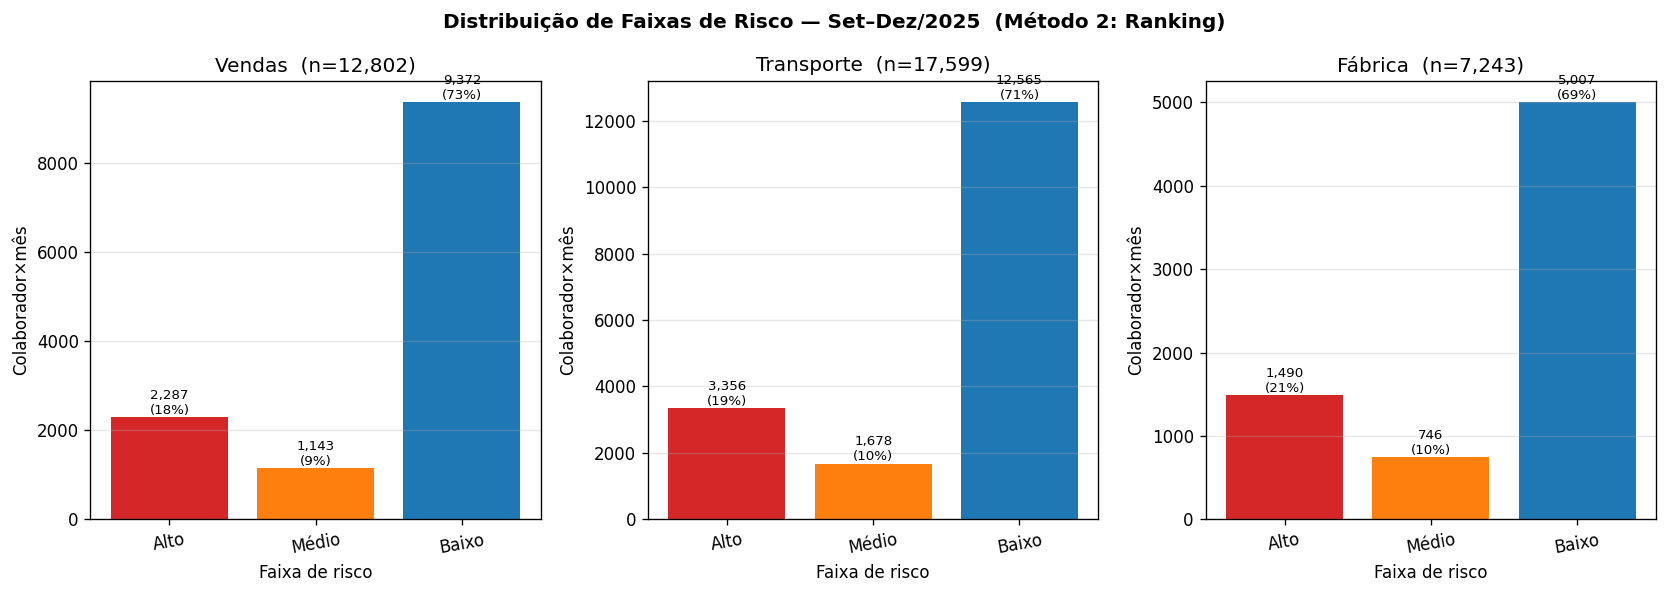

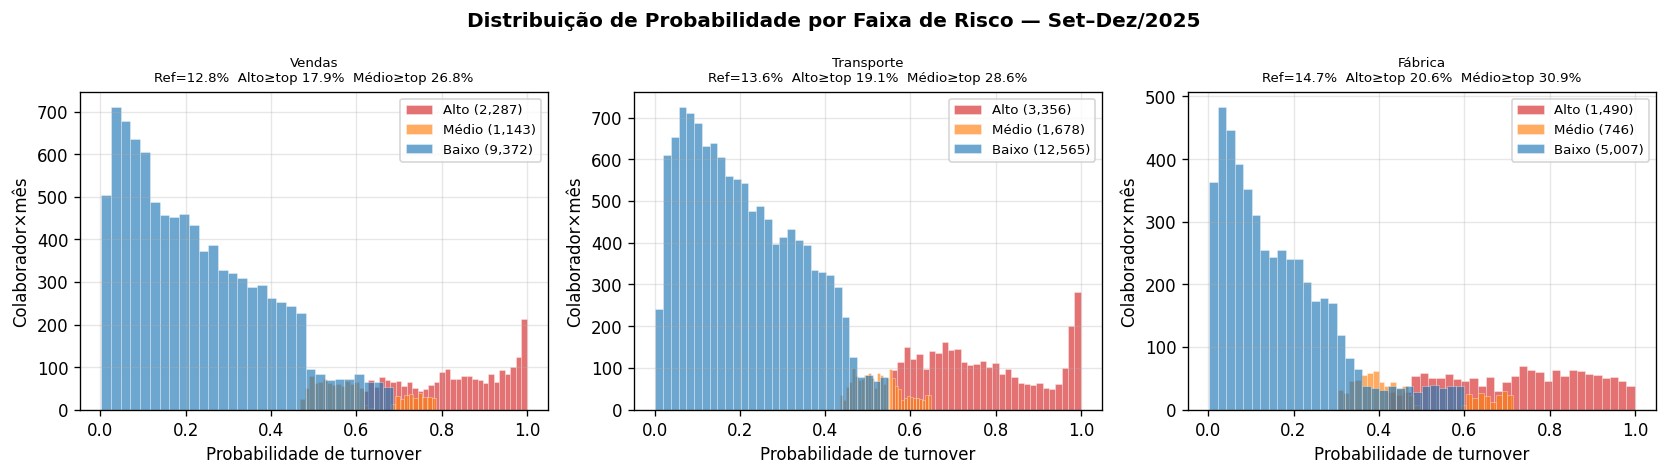

In [11]:

# ── Consolidar ────────────────────────────────────────────────
df_consolidado = pd.concat(score_frames, ignore_index=True)
df_consolidado = df_consolidado.sort_values(
    [COL_DATA, "proba_turnover"], ascending=[True, False]
).reset_index(drop=True)

print(f"Score consolidado : {len(df_consolidado):,} linhas  "
      f"({df_consolidado[COL_ID].nunique():,} IDs únicos × "
      f"{df_consolidado[COL_DATA].nunique()} meses)")

print("\nDistribuição grupo × faixa (total período):")
pivot_total = (
    df_consolidado.groupby([COL_GRUPO, "grupo_risco"])
    .size().unstack(fill_value=0)
)
for col in ["Alto", "Médio", "Baixo"]:
    if col not in pivot_total.columns:
        pivot_total[col] = 0
pivot_total = pivot_total[["Alto", "Médio", "Baixo"]]
pivot_total["Total"] = pivot_total.sum(axis=1)
print(pivot_total.to_string())

# ── Salvar ────────────────────────────────────────────────────
out_parquet = REPORTS_DIR / "score_risco_consolidado.parquet"
out_csv     = REPORTS_DIR / "score_risco_consolidado.csv"
df_consolidado.to_parquet(out_parquet, index=False)
df_consolidado.to_csv(out_csv, index=False, encoding="utf-8-sig")
print(f"\n✓ score_risco_consolidado.parquet salvo  ({out_parquet})")
print(f"✓ score_risco_consolidado.csv salvo")

# ── Cores e ordem ────────────────────────────────────────────
ORDEM_FAIXAS = ["Alto", "Médio", "Baixo"]
CORES_FAIXAS = {"Alto": "#d62728", "Médio": "#ff7f0e", "Baixo": "#1f77b4"}

# ── Plot 1: Distribuição de faixas por grupo ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, grupo in zip(axes, GRUPOS):
    df_g   = df_consolidado[df_consolidado[COL_GRUPO] == grupo]
    counts = df_g["grupo_risco"].value_counts().reindex(ORDEM_FAIXAS, fill_value=0)
    bars   = ax.bar(counts.index, counts.values,
                    color=[CORES_FAIXAS[f] for f in counts.index])
    for bar, val in zip(bars, counts.values):
        pct = val / len(df_g) * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                f"{val:,}\n({pct:.0f}%)", ha="center", va="bottom", fontsize=8)
    ax.set(title=f"{grupo}  (n={len(df_g):,})", ylabel="Colaborador×mês",
           xlabel="Faixa de risco")
    ax.tick_params(axis="x", labelrotation=10)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Distribuição de Faixas de Risco — Set–Dez/2025  (Método 2: Ranking)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
fig_path = FIGURES_DIR / "distribuicao_risco_grupos.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# ── Plot 2: Histograma de probabilidade colorido por faixa ───
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, grupo in zip(axes, GRUPOS):
    df_g = df_consolidado[df_consolidado[COL_GRUPO] == grupo]
    r    = rate_params[grupo]
    for faixa in ORDEM_FAIXAS:
        vals = df_g.loc[df_g["grupo_risco"] == faixa, "proba_turnover"]
        ax.hist(vals, bins=30, alpha=0.65, color=CORES_FAIXAS[faixa],
                label=f"{faixa} ({len(vals):,})", edgecolor="white", linewidth=0.3)
    ax.set(title=grupo, xlabel="Probabilidade de turnover", ylabel="Colaborador×mês")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    # Anotação das taxas de referência
    ax.set_title(f"{grupo}\nRef={r['ref_rate']*100:.1f}%  "
                 f"Alto≥top {r['alto_pct']*100:.1f}%  "
                 f"Médio≥top {(r['alto_pct']+r['medio_pct'])*100:.1f}%",
                 fontsize=8)

fig.suptitle("Distribuição de Probabilidade por Faixa de Risco — Set–Dez/2025",
             fontsize=12, fontweight="bold")
plt.tight_layout()
hist_path = FIGURES_DIR / "histograma_proba_grupos.png"
plt.savefig(hist_path, dpi=150, bbox_inches="tight")
plt.show(); plt.close()


## 5 · Top-10 Risco Alto por Grupo (mês mais recente)

In [12]:

mes_mais_recente = df_consolidado[COL_DATA].max()
df_recente       = df_consolidado[df_consolidado[COL_DATA] == mes_mais_recente]

print(f"Mês mais recente : {mes_mais_recente.strftime('%Y-%m')}")
print(f"Total de colaboradores neste mês : {len(df_recente):,}\n")

cols_show = [COL_ID, "proba_turnover", "grupo_risco"]

for grupo in GRUPOS:
    df_g = df_recente[
        (df_recente[COL_GRUPO] == grupo) &
        (df_recente["grupo_risco"] == "Alto")
    ].sort_values("proba_turnover", ascending=False).head(10)

    n_alto = (df_recente[df_recente[COL_GRUPO] == grupo]["grupo_risco"] == "Alto").sum()
    print(f"\n── Top-10 Risco Alto — {grupo}  "
          f"({n_alto} colaboradores em risco Alto no mês) ──")
    if df_g.empty:
        print("  Nenhum colaborador em risco Alto.")
    else:
        print(df_g[cols_show].to_string(index=False))

print(f"\n{'='*65}")
print("✅ 08_score.ipynb concluído.")
print(f"{'='*65}")


Mês mais recente : 2025-12
Total de colaboradores neste mês : 9,630


── Top-10 Risco Alto — Vendas  (589 colaboradores em risco Alto no mês) ──
id_colaborador  proba_turnover grupo_risco
          6960          0.9994        Alto
         16241          0.9991        Alto
          1155          0.9989        Alto
          9611          0.9989        Alto
         21029          0.9983        Alto
         21427          0.9977        Alto
         21546          0.9976        Alto
         23376          0.9974        Alto
         18583          0.9973        Alto
         18762          0.9971        Alto

── Top-10 Risco Alto — Transporte  (858 colaboradores em risco Alto no mês) ──
id_colaborador  proba_turnover grupo_risco
         17143          0.9992        Alto
         14638          0.9983        Alto
          7304          0.9979        Alto
          3747          0.9978        Alto
         15697          0.9976        Alto
          2459          0.9976        Alto
 